In [2]:
pip install SurfaceTopography

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 45.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 10.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 97.7 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4━━━━━━━━━━━━━━━━━━━━━━━  3/10 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [SurfaceTopography]SurfaceTopography]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
eo-learn-io 0.10.0 requires rtree, which is not installed.
spectrum 0.9.0 requires easydev, which is not installed.
eo-learn-core 1.4.2 requires sentinelhub>=3.9.0, but you have sentinelhub 3.4.4 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
gens

In [4]:
import pandas as pd
from SurfaceTopography.IO import OPDx

# 1. Load the binary .opdx file
file_path = "az10xt.OPDx"
reader = OPDx.OPDxReader(file_path)

# 2. Extract the primary measurement surface profile
topography = reader.topography()

# 3. Convert the 2D height array into a structured DataFrame
height_matrix = topography.heights()
df = pd.DataFrame(height_matrix)

# 4. Save to CSV
output_csv = "converted_measurement.csv"
df.to_csv(output_csv, index=False, header=False)

print(f"Success! Saved data matrix to {output_csv}")


Success! Saved data matrix to converted_measurement.csv


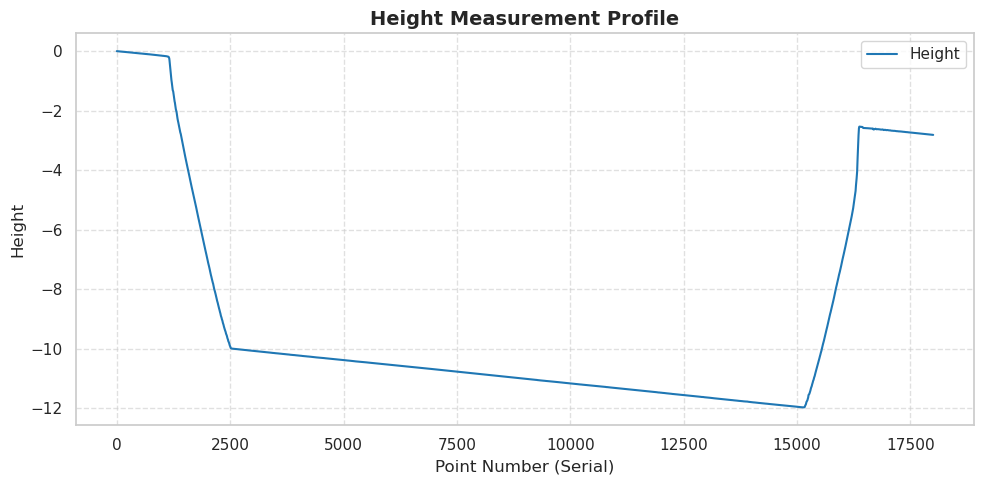

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Read file, force single-column reading, and skip malformed metadata lines
df = pd.read_csv(
    "converted_measurement.csv",
    header=None,
    on_bad_lines="skip",  # Ignores rows with inconsistent field counts
    engine="python",
)

# Extract height data (takes the first column found)
heights = pd.to_numeric(df.iloc[:, 0], errors="coerce").dropna().reset_index(drop=True)

# Generate serial numbers (1, 2, 3...) to act as the X-axis
serial_numbers = range(1, len(heights) + 1)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(serial_numbers, heights, color="#1f77b4", linewidth=1.5, label="Height")

# Formatting
plt.title("Height Measurement Profile", fontsize=14, fontweight="bold")
plt.xlabel("Point Number (Serial)", fontsize=12)
plt.ylabel("Height", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()

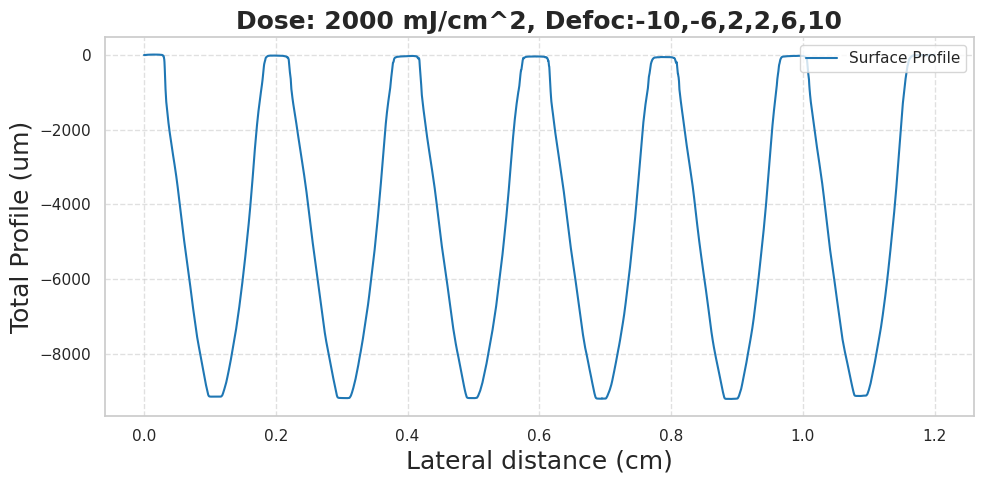

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Skip the first 27 lines (1-26 metadata + 27 header)
# 2. Force comma separation and extract only the first two columns using usecols
# 3. Manually name the columns since we skipped the header
df = pd.read_csv(
    "2608_2000dose line is 9.1 micron.csv",
    sep=",",
    skiprows=27, 
    usecols=[0, 1], 
    names=["Lateral_nm", "Height"],
    on_bad_lines="skip",
    engine="python"
)

# Safely convert to numeric, dropping any rows with text or missing values
x_data = pd.to_numeric(df["Lateral_nm"], errors="coerce")
y_data = pd.to_numeric(df["Height"], errors="coerce")

valid_mask = x_data.notna() & y_data.notna()
x_data = x_data[valid_mask]/1e7
y_data = y_data[valid_mask]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_data, y_data, color="#1f77b4", linewidth=1.5, label="Surface Profile")

# Formatting
plt.title("Dose: 2000 mJ/cm^2, Defoc:-10,-6,2,2,6,10", fontsize=18, fontweight="bold")
plt.xlabel("Lateral distance (cm)", fontsize=18)
plt.ylabel("Total Profile (um)", fontsize=18)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()

In [4]:
import numpy as np
np.min(y_data)

-9215.94335233623

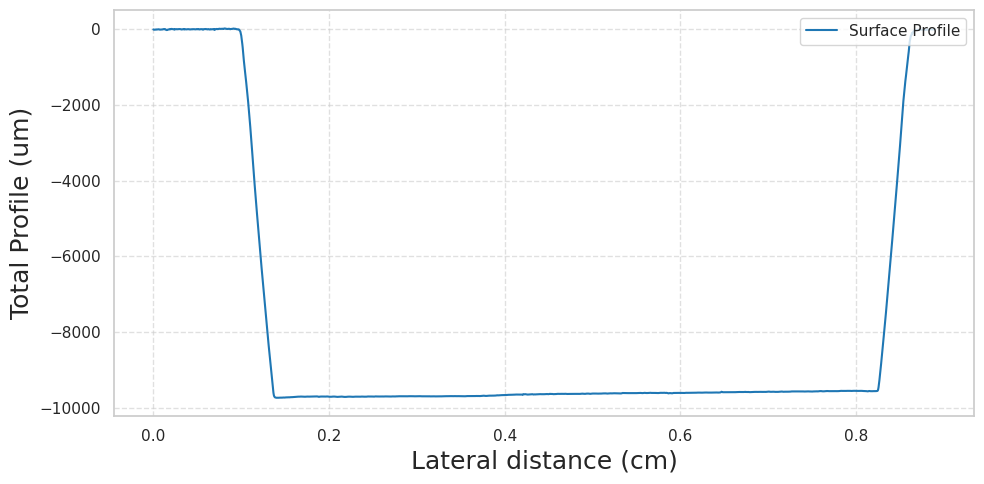

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Skip the first 27 lines (1-26 metadata + 27 header)
# 2. Force comma separation and extract only the first two columns using usecols
# 3. Manually name the columns since we skipped the header
df = pd.read_csv(
    "2608_dummy square is 9.6 micron.csv",
    sep=",",
    skiprows=27, 
    usecols=[0, 1], 
    names=["Lateral_nm", "Height"],
    on_bad_lines="skip",
    engine="python"
)

# Safely convert to numeric, dropping any rows with text or missing values
x_data = pd.to_numeric(df["Lateral_nm"], errors="coerce")
y_data = pd.to_numeric(df["Height"], errors="coerce")

valid_mask = x_data.notna() & y_data.notna()
x_data = x_data[valid_mask]/1e7
y_data = y_data[valid_mask]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_data, y_data, color="#1f77b4", linewidth=1.5, label="Surface Profile")

# Formatting
# plt.title("Dose: 2000 mJ/cm^2, Defoc:-10,-6,2,2,6,10", fontsize=18, fontweight="bold")
plt.xlabel("Lateral distance (cm)", fontsize=18)
plt.ylabel("Total Profile (um)", fontsize=18)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()